In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform
import optuna
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Импортируем инструменты для байесовского поиска
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# 1. Загрузка и подготовка данных
df = pd.read_csv('df.csv')
target_col = "Data Throughput (Mbps)"

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def evaluate_model(name, model, X_test, y_test, elapsed_time):
    y_pred = model.predict(X_test)
    return {
        "Метод": name,
        "Время (сек)": round(elapsed_time, 2),
        "MAE": round(mean_absolute_error(y_test, y_pred), 4),
        "MSE": round(mean_squared_error(y_test, y_pred), 4),
        "R2": round(r2_score(y_test, y_pred), 4)
    }


results = []
xgb = XGBRegressor(random_state=42, objective="reg:squarederror")

df

/Users/zip/PycharmProjects/fefu/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Signal Strength (dBm),Data Throughput (Mbps),BB60C Measurement (dBm),Network Type_4G,Network Type_5G,Network Type_LTE
0,-84.274113,1.863890,0.000000,0,0,0
1,-97.653121,5.132296,-95.810791,1,0,0
2,-87.046134,1.176985,-91.593861,0,0,1
3,-94.143159,68.596932,-90.642773,0,1,0
4,-94.564765,38.292038,-90.489100,0,1,0
...,...,...,...,...,...,...
16824,-92.024221,3.720856,-90.177947,1,0,0
16825,-87.579509,2.117080,-87.694985,0,0,1
16826,-90.451396,72.870842,-91.098875,0,1,0
16827,-85.661814,2.482843,0.000000,0,0,0


In [30]:
xgb_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2]
} # Итого: 4 * 5 * 4 = 80 комбинаций!

start = time.time()
grid_search = GridSearchCV(estimator=xgb, param_grid=xgb_grid, scoring="neg_mean_squared_error", cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)
time_grid = time.time() - start
results.append(evaluate_model("GridSearchCV", grid_search.best_estimator_, X_test, y_test, time_grid))


In [31]:
xgb_random_grid = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(2, 6),
    "learning_rate": uniform(0.01, 0.19)
}

start = time.time()
random_search = RandomizedSearchCV(estimator=xgb, param_distributions=xgb_random_grid, n_iter=40, scoring="neg_mean_squared_error", cv=3, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
time_random = time.time() - start
results.append(evaluate_model("RandomizedSearchCV", random_search.best_estimator_, X_test, y_test, time_random))

In [32]:
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    }
    model = XGBRegressor(**params, random_state=42, objective="reg:squarederror")
    return -cross_val_score(model, X_train, y_train, cv=3, scoring="neg_mean_squared_error", n_jobs=-1).mean()

start = time.time()
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=40)
time_bayes = time.time() - start

best_bayes_model = XGBRegressor(**study.best_params, random_state=42, objective="reg:squarederror")
best_bayes_model.fit(X_train, y_train)
results.append(evaluate_model("Bayesian (Optuna)", best_bayes_model, X_test, y_test, time_bayes))

,Метод,Время (сек),MAE,MSE,R2
0,GridSearchCV,3.41,6.4568,176.2943,0.7379
1,RandomizedSearchCV,1.32,6.4907,178.0983,0.7352
2,Bayesian (Optuna),3.19,6.4495,176.2948,0.7379


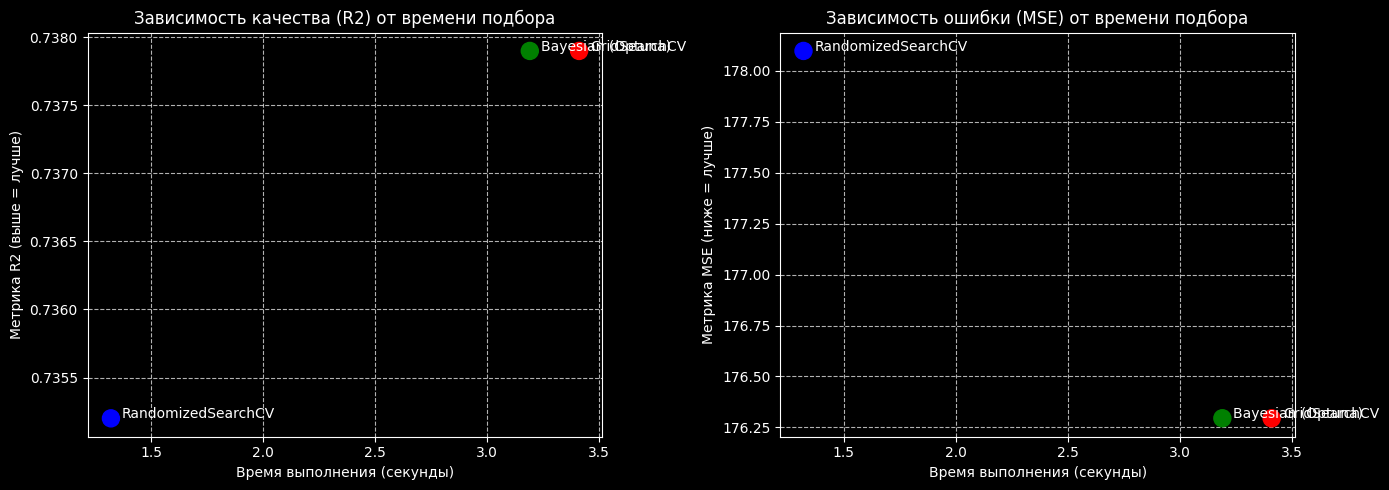


Параметры:
Grid: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 400}
Random: {'learning_rate': np.float64(0.06629196608377566), 'max_depth': 2, 'n_estimators': 164}
Bayesian: {'n_estimators': 366, 'max_depth': 2, 'learning_rate': 0.011927483644421921}


In [33]:
results_df = pd.DataFrame(results)
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['red', 'blue', 'green']

axes[0].scatter(results_df["Время (сек)"], results_df["R2"], color=colors, s=150, zorder=3)
for i, txt in enumerate(results_df["Метод"]):
    axes[0].annotate(txt, (results_df["Время (сек)"][i], results_df["R2"][i]), xytext=(8, 0), textcoords='offset points')
axes[0].set_xlabel("Время выполнения (секунды)")
axes[0].set_ylabel("Метрика R2 (выше = лучше)")
axes[0].set_title("Зависимость качества (R2) от времени подбора")
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].scatter(results_df["Время (сек)"], results_df["MSE"], color=colors, s=150, zorder=3)
for i, txt in enumerate(results_df["Метод"]):
    axes[1].annotate(txt, (results_df["Время (сек)"][i], results_df["MSE"][i]), xytext=(8, 0), textcoords='offset points')
axes[1].set_xlabel("Время выполнения (секунды)")
axes[1].set_ylabel("Метрика MSE (ниже = лучше)")
axes[1].set_title("Зависимость ошибки (MSE) от времени подбора")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\nПараметры:")
print("Grid:", grid_search.best_params_)
print("Random:", random_search.best_params_)
print("Bayesian:", study.best_params)